# Final Project: Classify Waste Products Using Transfer Learning

This notebook trains a VGG16-based image classifier to distinguish organic waste (`O`) from recyclable waste (`R`). It follows the ten tasks in the assignment and uses the provided 1,200-image split.

## Task 1 — Print the TensorFlow version

In [1]:
import os
from pathlib import Path
import certifi

# Keep downloaded model weights and plotting settings inside this project.
PROJECT_ROOT = Path.cwd()
os.environ["KERAS_HOME"] = str(PROJECT_ROOT / ".keras")
os.environ["MPLCONFIGDIR"] = str(PROJECT_ROOT / ".matplotlib")
os.environ["SSL_CERT_FILE"] = certifi.where()
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import tensorflow as tf
print(tf.__version__)

2.21.0


## Dataset setup

The notebook downloads the assignment's Organic/Recyclable image split the first time it runs. It places the archive and extracted images under `data/` so they stay out of the notebook directory.

In [2]:
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

SEED = 42
DATA_ROOT = PROJECT_ROOT / "data"
ARCHIVE_DIR = DATA_ROOT / "downloads"
ARCHIVE_PATH = ARCHIVE_DIR / "o-vs-r-split-reduced-1200.zip"
DATASET_DIR = DATA_ROOT / "o-vs-r-split"
DATASET_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/kd6057VPpABQ2FqCbgu9YQ/o-vs-r-split-reduced-1200.zip"

required_folders = [
    DATASET_DIR / "train" / "O",
    DATASET_DIR / "train" / "R",
    DATASET_DIR / "test" / "O",
    DATASET_DIR / "test" / "R",
]
if not all(folder.is_dir() for folder in required_folders):
    ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)
    if not ARCHIVE_PATH.exists():
        print("Downloading the waste-classification dataset...")
        urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH)
    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        archive.extractall(DATA_ROOT)

assert all(folder.is_dir() for folder in required_folders), "The waste dataset folders were not found after extraction."
print("Dataset ready:", DATASET_DIR)
print("Classes:", ["O (Organic)", "R (Recyclable)"])

Dataset ready: /Users/prodbyjake_/Documents/final project/data/o-vs-r-split
Classes: ['O (Organic)', 'R (Recyclable)']


## Image size, batch size, and data generators

In [3]:
img_rows, img_cols = 150, 150
batch_size = 32
n_epochs = 3
n_classes = 2
val_split = 0.2
verbosity = 2
path = str(DATASET_DIR / "train") + "/"
path_test = str(DATASET_DIR / "test") + "/"
input_shape = (img_rows, img_cols, 3)
labels = ["O", "R"]
seed = SEED

np.random.seed(seed)
tf.random.set_seed(seed)

train_datagen = ImageDataGenerator(
    validation_split=val_split,
    rescale=1.0 / 255.0,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)
val_datagen = ImageDataGenerator(
    validation_split=val_split,
    rescale=1.0 / 255.0,
)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    directory=path,
    seed=seed,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True,
    target_size=(img_rows, img_cols),
    subset="training",
)
validation_generator = val_datagen.flow_from_directory(
    directory=path,
    seed=seed,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False,
    target_size=(img_rows, img_cols),
    subset="validation",
)
print("Class indices:", train_generator.class_indices)

Found 800 images belonging to 2 classes.


Found 200 images belonging to 2 classes.


Class indices: {'O': 0, 'R': 1}


## Task 2 — Create `test_generator` using `test_datagen`

In [4]:
test_generator = test_datagen.flow_from_directory(
    directory=path_test,
    class_mode="binary",
    seed=seed,
    batch_size=batch_size,
    shuffle=False,
    target_size=(img_rows, img_cols),
)

Found 200 images belonging to 2 classes.


## Task 3 — Print the length of `train_generator`

In [5]:
print(len(train_generator))

25


## Build the VGG16 feature-extraction model

In [6]:
vgg16_base = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
)
flattened_features = Flatten(name="flatten_features")(vgg16_base.output)
base_model = tf.keras.Model(
    inputs=vgg16_base.input,
    outputs=flattened_features,
    name="vgg16_feature_extractor",
)
base_model.trainable = False

model = Sequential(
    [
        base_model,
        Dense(512, activation="relu", name="dense_1"),
        Dropout(0.3, name="dropout_1"),
        Dense(512, activation="relu", name="dense_2"),
        Dropout(0.3, name="dropout_2"),
        Dense(1, activation="sigmoid", name="waste_class_probability"),
    ],
    name="waste_classifier",
)
# Keep the task name explicit for the accuracy-curve and prediction tasks.
extract_feat_model = model

       0/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/58889256 ━━━━━━━━━━━━━━━━━━━━ 9:04 9us/step

   49152/58889256 ━━━━━━━━━━━━━━━━━━━━ 5:08 5us/step

   81920/58889256 ━━━━━━━━━━━━━━━━━━━━ 4:56 5us/step

  114688/58889256 ━━━━━━━━━━━━━━━━━━━━ 3:57 4us/step

...

54214656/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

55803904/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

57376768/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

58294272/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## Task 4 — Print the model summary

In [7]:
model.summary()

Model: "waste_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16_feature_extractor         │ (None, 8192)           │    14,714,688 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ waste_class_probability (Dense) │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,172,673 (73.14 MB)

 Trainable params: 4,457,985 (17.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Task 5 — Compile and train the feature-extraction model

In [8]:
model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

history_extract = model.fit(
    train_generator,
    steps_per_epoch=5,
    epochs=n_epochs,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=verbosity,
)

Epoch 1/3


W0000 00:00:1790503069.183530 1385456 cpu_utils.cc:145] Failed to get CPU frequency: 0 Hz
W0000 00:00:1790503069.187412 1385456 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: goo.gle/debugproto    type: "CPU" model: "0" num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.5.0" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456


5/5 - 14s - 3s/step - accuracy: 0.4812 - loss: 0.7447 - val_accuracy: 0.5150 - val_loss: 0.7210


Epoch 2/3


5/5 - 14s - 3s/step - accuracy: 0.5437 - loss: 0.7031 - val_accuracy: 0.4950 - val_loss: 0.7051


Epoch 3/3


5/5 - 15s - 3s/step - accuracy: 0.5938 - loss: 0.6841 - val_accuracy: 0.5400 - val_loss: 0.6922


## Task 6 — Plot feature-extraction training and validation accuracy

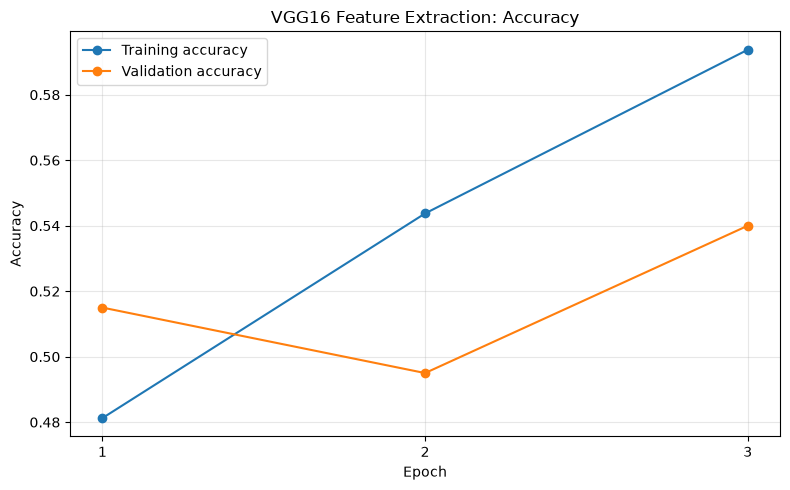

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history_extract.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(history_extract.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("VGG16 Feature Extraction: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(n_epochs), range(1, n_epochs + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Prepare the fine-tuned model

In [10]:
fine_tune_model = tf.keras.models.clone_model(extract_feat_model)
fine_tune_model.set_weights(extract_feat_model.get_weights())
fine_tune_base = fine_tune_model.layers[0]
fine_tune_base.trainable = True

# Freeze earlier VGG16 layers and fine-tune the last convolutional block.
set_trainable = False
for layer in fine_tune_base.layers:
    if layer.name == "block5_conv3":
        set_trainable = True
    layer.trainable = set_trainable

print("Trainable VGG16 layers:", [layer.name for layer in fine_tune_base.layers if layer.trainable])

Trainable VGG16 layers: ['block5_conv3', 'block5_pool', 'flatten_features']


## Train the fine-tuned model

In [11]:
fine_tune_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)
history_fine_tune = fine_tune_model.fit(
    train_generator,
    steps_per_epoch=5,
    epochs=n_epochs,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=verbosity,
)

Epoch 1/3


W0000 00:00:1790503120.248637 1386217 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: goo.gle/debugproto    type: "CPU" model: "0" num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.5.0" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456


5/5 - 16s - 3s/step - accuracy: 0.4875 - loss: 0.7259 - val_accuracy: 0.5800 - val_loss: 0.6757


Epoch 2/3


5/5 - 15s - 3s/step - accuracy: 0.6000 - loss: 0.6877 - val_accuracy: 0.6150 - val_loss: 0.6596


Epoch 3/3


5/5 - 16s - 3s/step - accuracy: 0.5938 - loss: 0.6798 - val_accuracy: 0.6500 - val_loss: 0.6453


## Task 7 — Plot fine-tuned training and validation loss

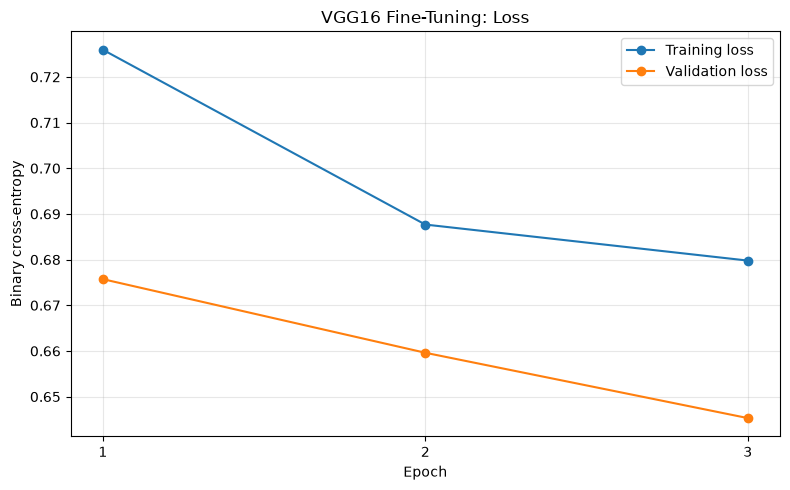

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history_fine_tune.history["loss"], marker="o", label="Training loss")
plt.plot(history_fine_tune.history["val_loss"], marker="o", label="Validation loss")
plt.title("VGG16 Fine-Tuning: Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.xticks(range(n_epochs), range(1, n_epochs + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Task 8 — Plot fine-tuned training and validation accuracy

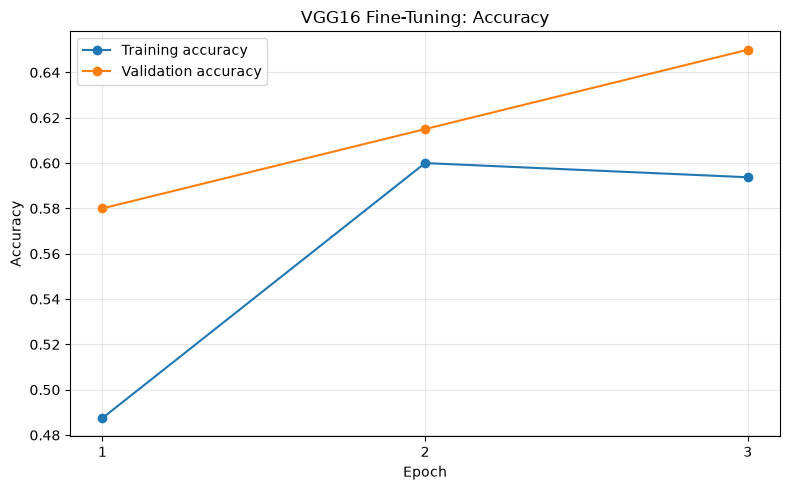

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history_fine_tune.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(history_fine_tune.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("VGG16 Fine-Tuning: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(n_epochs), range(1, n_epochs + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Test-image prediction helper

In [14]:
class_names = {index: name for name, index in test_generator.class_indices.items()}

def plot_test_prediction(selected_model, model_title, index_to_plot=1):
    if not 0 <= index_to_plot < test_generator.samples:
        raise IndexError("index_to_plot is outside the test set")
    batch_index, image_index = divmod(index_to_plot, batch_size)
    images, batch_labels = test_generator[batch_index]
    image = images[image_index]
    true_index = int(batch_labels[image_index])
    probability_recyclable = float(selected_model.predict(image[np.newaxis, ...], verbose=0)[0][0])
    predicted_index = int(probability_recyclable >= 0.5)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"{model_title}\nTrue: {class_names[true_index]} | "
        f"Predicted: {class_names[predicted_index]} ({probability_recyclable if predicted_index else 1 - probability_recyclable:.1%})"
    )
    plt.tight_layout()
    plt.show()
    print(
        f"{model_title}: true={class_names[true_index]}, "
        f"predicted={class_names[predicted_index]}, "
        f"P(R)={probability_recyclable:.3f}"
    )

## Task 9 — Plot test image 1 using the Extract Features Model

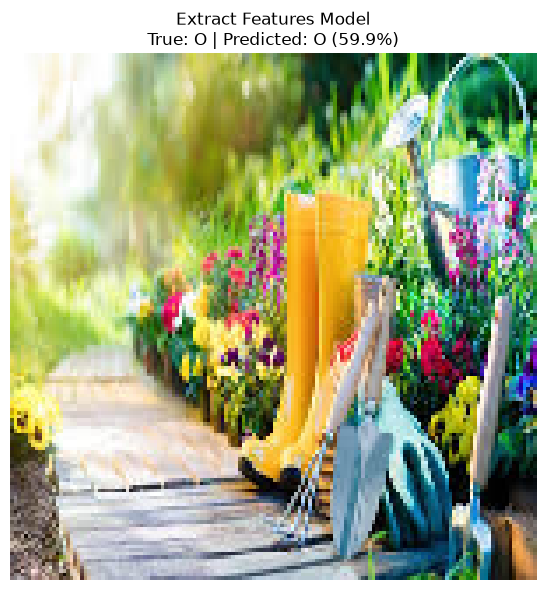

Extract Features Model: true=O, predicted=O, P(R)=0.401


In [15]:
index_to_plot = 1
plot_test_prediction(extract_feat_model, "Extract Features Model", index_to_plot=index_to_plot)

## Task 10 — Plot test image 1 using the Fine-Tuned Model

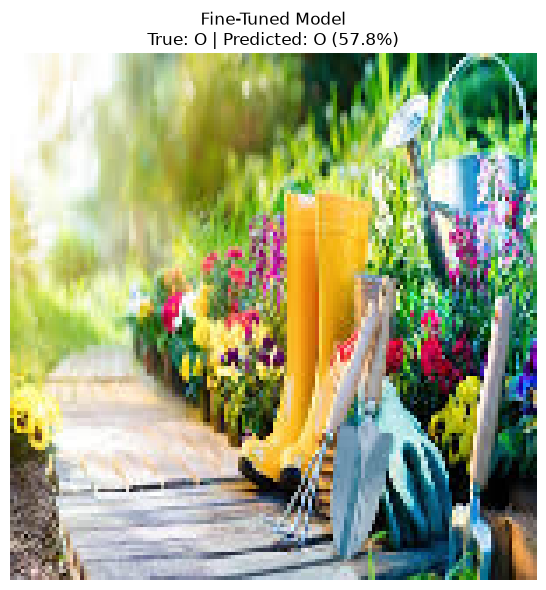

Fine-Tuned Model: true=O, predicted=O, P(R)=0.422


In [16]:
plot_test_prediction(fine_tune_model, "Fine-Tuned Model", index_to_plot=index_to_plot)